In [4]:
# %load_ext autoreload
# %autoreload 2

import os

from functools import partial

if "KERAS_BACKEND" not in os.environ:
    os.environ["KERAS_BACKEND"] = "jax"

import blackjax
import bayesflow as bf
import jax
import jax.numpy as jnp
import keras
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from priors import truncated_normal_rvs
from mcmc import model_nle, warmup, inference_loop_multiple_chains
from plots import create_profile_likelihood_plot, create_pushforward_plot_rdmc
from rdmc import rdmc_experiment_simple
from density import rdmc_approx_likelihood

jax.config.update("jax_enable_x64", True)


In [5]:
def prior_fun_train(
    drift_c_intercept_loc=0.05,
    drift_c_intercept_scale=0.05,
    drift_c_slope_loc=0.5,
    drift_c_slope_scale=0.1,
    amp_shape=10,
    amp_scale=2,
    tau_shape=8,
    tau_scale=10,
    sd_true_shape=80,
    sd_true_scale=0.05,
    threshold_shape=100,
    threshold_scale=0.7,
    t0_loc=300,
    t0_scale=200,
    rng=np.random.default_rng(2025),
):
    drift_c_intercept = truncated_normal_rvs(drift_c_intercept_loc, drift_c_intercept_scale, random_state=rng)
    drift_c_slope = truncated_normal_rvs(drift_c_slope_loc, drift_c_slope_scale, random_state=rng)
    amp = rng.gamma(shape=amp_shape, scale=amp_scale)
    tau = rng.gamma(shape=tau_shape, scale=tau_scale)
    s_true = rng.gamma(shape=sd_true_shape, scale=sd_true_scale)
    b = rng.gamma(shape=threshold_shape, scale=threshold_scale)
    t0 = truncated_normal_rvs(t0_loc, t0_scale, random_state=rng)

    return {
        "v_c_intercept": drift_c_intercept,
        "v_c_slope": drift_c_slope,
        "amp": amp,
        "tau": tau,
        "s_true": s_true,
        "b": b,
        "t0": t0
    }

def simulator_fun(**kwargs):
    return rdmc_experiment_simple(**kwargs, t_max=5000, a_shape=2, s_false=4)


def meta(batch_size):
    num_obs = np.random.default_rng(2025).integers(250, 750)

    return dict(num_obs=num_obs)

simulator = bf.simulators.make_simulator([prior_fun_train, simulator_fun], meta_fn=meta)

In [6]:
def prior_log_prob(x):
    x = jnp.exp(x)
    # x shape: (..., 7)
    v_c_intercept_lp = jax.scipy.stats.norm.logpdf(x[..., 0], loc=0.05, scale=0.05)
    v_c_slope_lp     = jax.scipy.stats.norm.logpdf(x[..., 1], loc=0.5, scale=0.1)
    tau_lp           = jax.scipy.stats.gamma.logpdf(x[..., 2], a=8, scale=10)
    amp_lp           = jax.scipy.stats.gamma.logpdf(x[..., 3], a=10, scale=2)
    s_true_lp        = jax.scipy.stats.gamma.logpdf(x[..., 4], a=80, scale=0.05)
    b_lp             = jax.scipy.stats.gamma.logpdf(x[..., 5], a=100, scale=0.7)
    t0_lp            = jax.scipy.stats.norm.logpdf(x[..., 6], loc=300, scale=200)
    return (
        v_c_intercept_lp
        + v_c_slope_lp
        + tau_lp
        + amp_lp
        + s_true_lp
        + b_lp
        + t0_lp
    )

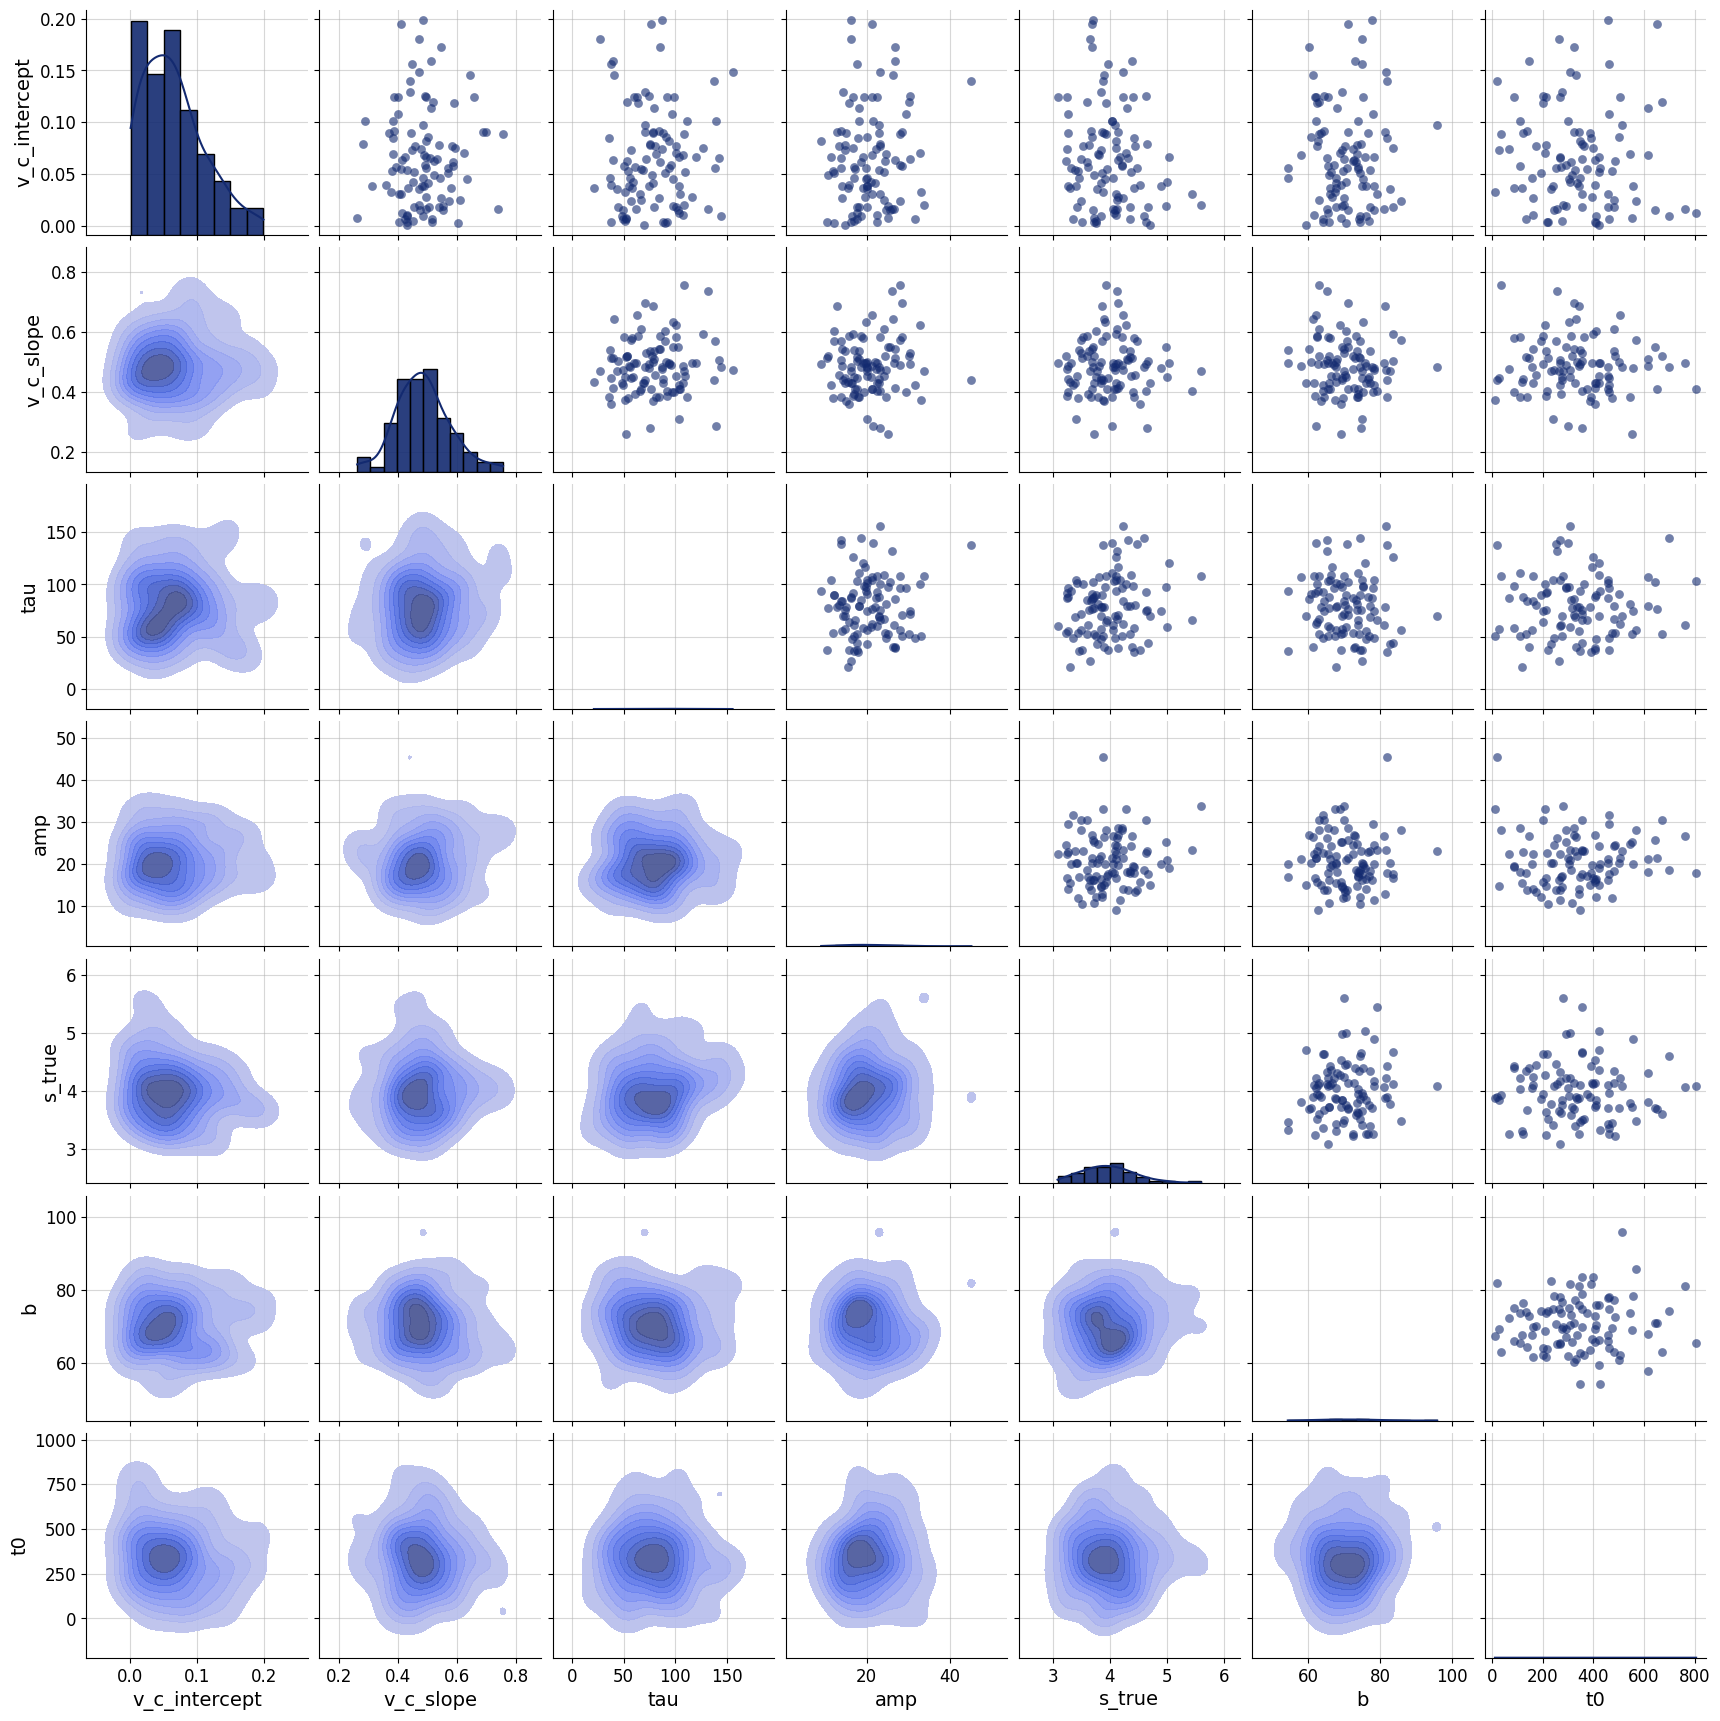

In [7]:
param_names = ["v_c_intercept", "v_c_slope", "tau", "amp", "s_true", "b", "t0"]

data = simulator.sample(100)

fig = bf.diagnostics.plots.pairs_samples(
    samples=data,
    variable_keys=param_names,
    variable_names=param_names
)

In [8]:
test_data = simulator.sample(1)
# test_data["x"][..., 0] *= 1000
prior_draws = np.array([test_data[p] for p in param_names]).squeeze()

In [10]:
# approximator = keras.saving.load_model("checkpoints/rdmc_nle_spline_shallow_20.keras")
approximator = keras.saving.load_model("outputs/rdmc/flow_matching/epochs=10/inference-method=flow_matching/mlp_depth=3/mlp_residual=true/mlp_width=6/checkpoints/model.keras")

In [11]:
approximator.inference_network.integrate_kwargs["steps"] = 100 # "adaptive"
# approximator.inference_network.integrate_kwargs["min_steps"] = 1
# approximator.inference_network.integrate_kwargs["max_steps"] = 100
# approximator.inference_network.integrate_kwargs["start_time"] = 0.0
# approximator.inference_network.integrate_kwargs["stop_time"] = 1.0
approximator.inference_network.integrate_kwargs["method"] = "rk45"

In [14]:
np.exp(approximator.log_prob(test_data))

array([[2.65733123e-01, 8.04228857e-02, 7.41863012e-01, 8.74783516e-01,
        3.44114602e-01, 7.39065945e-01, 8.65976095e-01, 1.03112713e-01,
        4.69638437e-01, 7.41863012e-01, 1.83016822e-01, 2.86617547e-01,
        8.72620225e-01, 6.48767054e-01, 2.75751829e-01, 7.57778227e-01,
        2.16722399e-01, 3.44114602e-01, 2.45913281e-04, 6.43553771e-03,
        5.97129524e-01, 8.59166145e-01, 7.12697029e-01, 7.12697029e-01,
        3.71599525e-01, 6.85662091e-01, 5.82329929e-01, 8.49008322e-01,
        3.82807059e-03, 8.72620225e-01, 3.39491129e-01, 7.95570970e-01,
        8.02029312e-01, 1.15017304e-02, 3.81727159e-01, 6.13410354e-01,
        2.54089274e-02, 1.50810882e-01, 1.61014691e-01, 7.31979549e-01,
        7.28606582e-01, 2.61579268e-02, 2.30748519e-01, 6.46120667e-01,
        4.94607627e-01, 4.02043372e-01, 3.02071899e-01, 8.74566734e-01,
        1.28844008e-01, 8.29257250e-01, 7.58996308e-02, 6.31316900e-01,
        2.54821172e-03, 6.03251457e-01, 8.13906312e-01, 2.013671

In [20]:
def approx_likelihood(data):
    rt, choice = data["x"][0, :, 0], data["x"][0, :, 1]
    s_false = 4.0
    a_shape = 2.0
    return rdmc_approx_likelihood(
        rt,
        choice,
        data["v_c_intercept"].squeeze(),
        data["v_c_slope"].squeeze(),
        data["amp"].squeeze(),
        data["tau"].squeeze(),
        data["s_true"].squeeze(),
        s_false,
        data["b"].squeeze(),
        data["t0"].squeeze(),
        a_shape,
        2500.0,
        5.0,
    )

In [21]:
approx_likelihood(test_data).sum()

Array(-2841.25538595, dtype=float64)

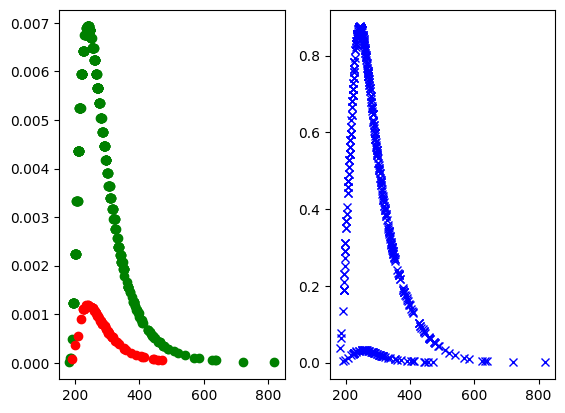

In [37]:
prob_nle = np.exp(approximator.log_prob(test_data).squeeze())
prob_approx = np.exp(approx_likelihood(test_data))

fig, (ax1, ax2) = plt.subplots(1, 2)

rt, choice = test_data["x"][0, :, 0], test_data["x"][0, :, 1]

ax2.plot(rt[choice==1], prob_nle[choice==1], "x", color="blue")
ax1.plot(rt[choice==1], prob_approx[choice==1], "o", color="green")
ax2.plot(rt[choice==0], prob_nle[choice==0], "x", color="blue")
ax1.plot(rt[choice==0], prob_approx[choice==0], "o", color="red")

In [38]:
prob_nle / prob_approx

array([ 148.15451578,  155.26410258,  115.35623906,  127.6932453 ,
        144.11118059,  130.68688344,  129.31558574,  152.41516606,
        138.05452209,  115.35623906,  145.47449051,  138.50237462,
        127.37746701,  136.66267075,  143.13589438,  117.83098078,
        149.58208042,  144.11118059,   35.53716411,   17.3102025 ,
        134.04310595,  124.53273703,  120.01387349,  120.01387349,
        134.93213821,  135.8444212 ,  130.72090601,  130.92873204,
         78.97524684,  127.37746701,  142.17492417,  133.6789193 ,
        128.7064876 ,   29.68565508,  138.60960062,  116.83156885,
         22.94762746,  147.83982391,  147.23162984,  129.43381659,
        113.29492591,  131.39142152,  148.35322339,  108.80281645,
        135.68373794,  135.99303776,  145.97039065,  126.27071185,
        155.32960406,  122.97729369,  739.02792322,  120.24209155,
         33.88643988,  135.41735214,  130.61246157,   33.13308221,
        155.95719465,  114.60249186,   29.14436347,  137.60762

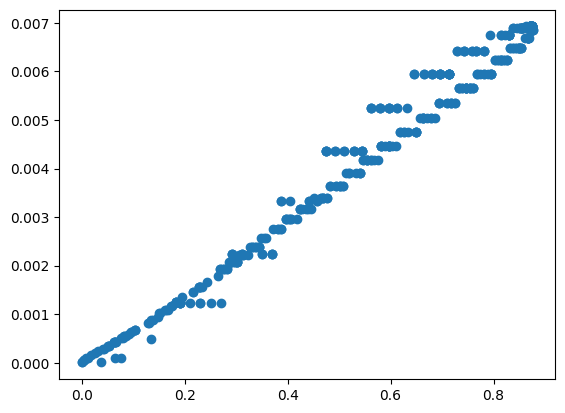

In [39]:
plt.scatter(prob_nle[choice==1], prob_approx[choice==1])

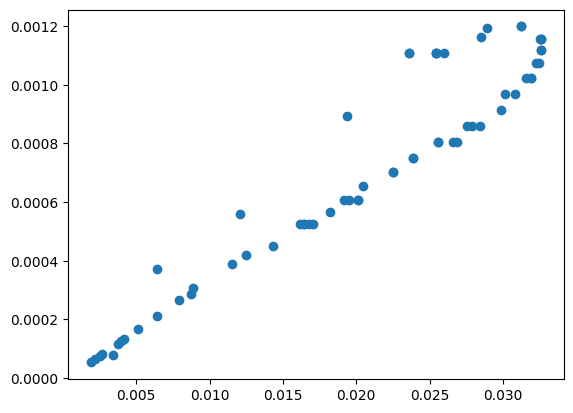

In [40]:
plt.scatter(prob_nle[choice==0], prob_approx[choice==0])

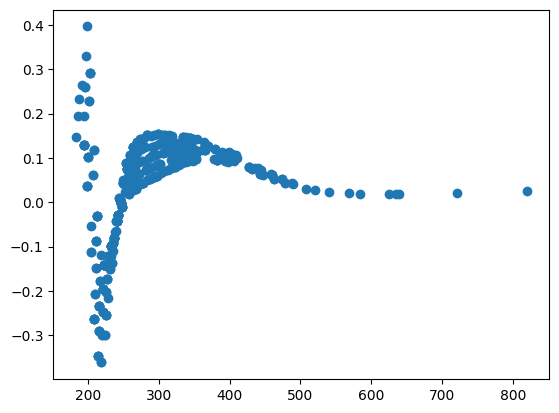

In [41]:
prob_std_diff = (prob_nle - prob_nle.mean()) / prob_nle.std() - (prob_approx - prob_approx.mean()) / prob_approx.std()
plt.scatter(rt[choice==1], prob_std_diff[choice==1])

In [32]:
test_data["t0"] + test_data["tau"]

array([[226.472847]])

In [34]:
rt[choice==0][prob_std_diff[choice==0].argmin()]

233.77904391072232

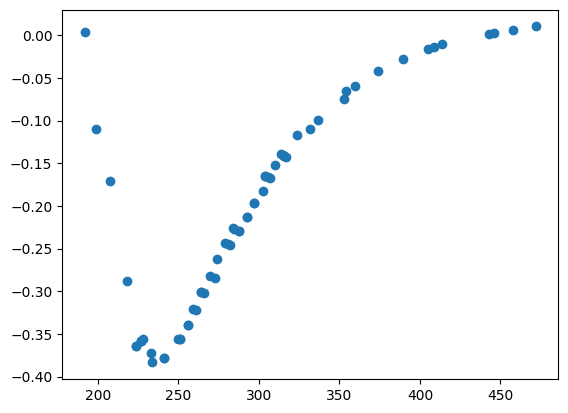

In [29]:
plt.scatter(rt[choice==0], prob_std_diff[choice==0])

In [54]:
init_position = np.array([0.1, 0.5, 50, 20, 4, 75, test_data["x"][..., 0].min() / 2 * 1000])

In [14]:
ll_fun = model_nle(test_data, approximator)

def likelihood(x):
    return ll_fun(x) + prior_log_prob(x)

In [15]:
likelihood(jnp.log(prior_draws))

Array(2270.51328124, dtype=float64)

In [54]:
# jax.grad(likelihood)(jnp.log(prior_draws))

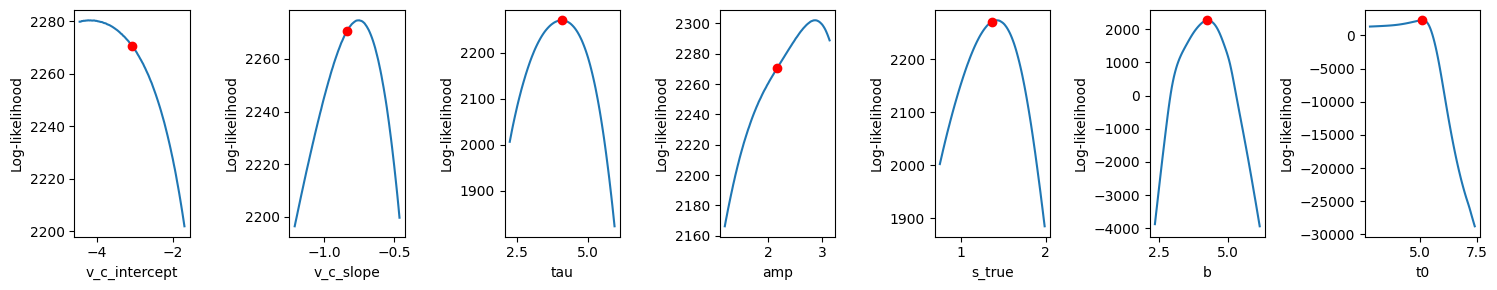

In [16]:
_ = create_profile_likelihood_plot(likelihood, jnp.log(prior_draws), param_names)

In [14]:
rng_key = jax.random.key(2025)
    
rng_key, warmup_key = jax.random.split(rng_key)

kernel, last_state, warmup_parameters = warmup(
    blackjax.nuts,
    likelihood,
    jnp.log(init_position),
    1000,
    warmup_key,
    # target_acceptance_rate=0.9,
    progress_bar=True,
)

Running window adaptation


In [21]:
warmup_parameters

{'step_size': Array(0.27210742, dtype=float32, weak_type=True),
 'inverse_mass_matrix': Array([0.12337065, 0.00134553, 0.01462876, 0.00400711, 0.0017467 ,
        0.00161133, 0.00043191], dtype=float32)}

In [22]:
for p1, p2, p3 in zip(np.exp(last_state.position), init_position, prior_draws):
    print(p1, p2, p3)

0.0043683783 0.1 0.04655966929428123
0.43978426 0.5 0.4333307554599998
41.07465 50.0 60.693803093803425
20.98931 20.0 8.705716739910784
3.094717 4.0 3.9404136847538136
62.123814 75.0 70.83526527404787
174.93633 93.88952195536116 165.77904391072232


In [17]:
num_chains = 4

last_states = jax.vmap(lambda x: last_state)(np.arange(num_chains))

trace = inference_loop_multiple_chains(
    rng_key, kernel, last_states, 500, num_chains
)

In [18]:
blackjax.diagnostics.potential_scale_reduction(trace.position)

Array([1.0009639, 1.0006241, 1.005945 , 1.0058907, 1.0034558, 1.0036254,
       1.006296 ], dtype=float32)

INFO:arviz.preview:arviz_base not installed
INFO:arviz.preview:arviz_stats not installed
INFO:arviz.preview:arviz_plots not installed


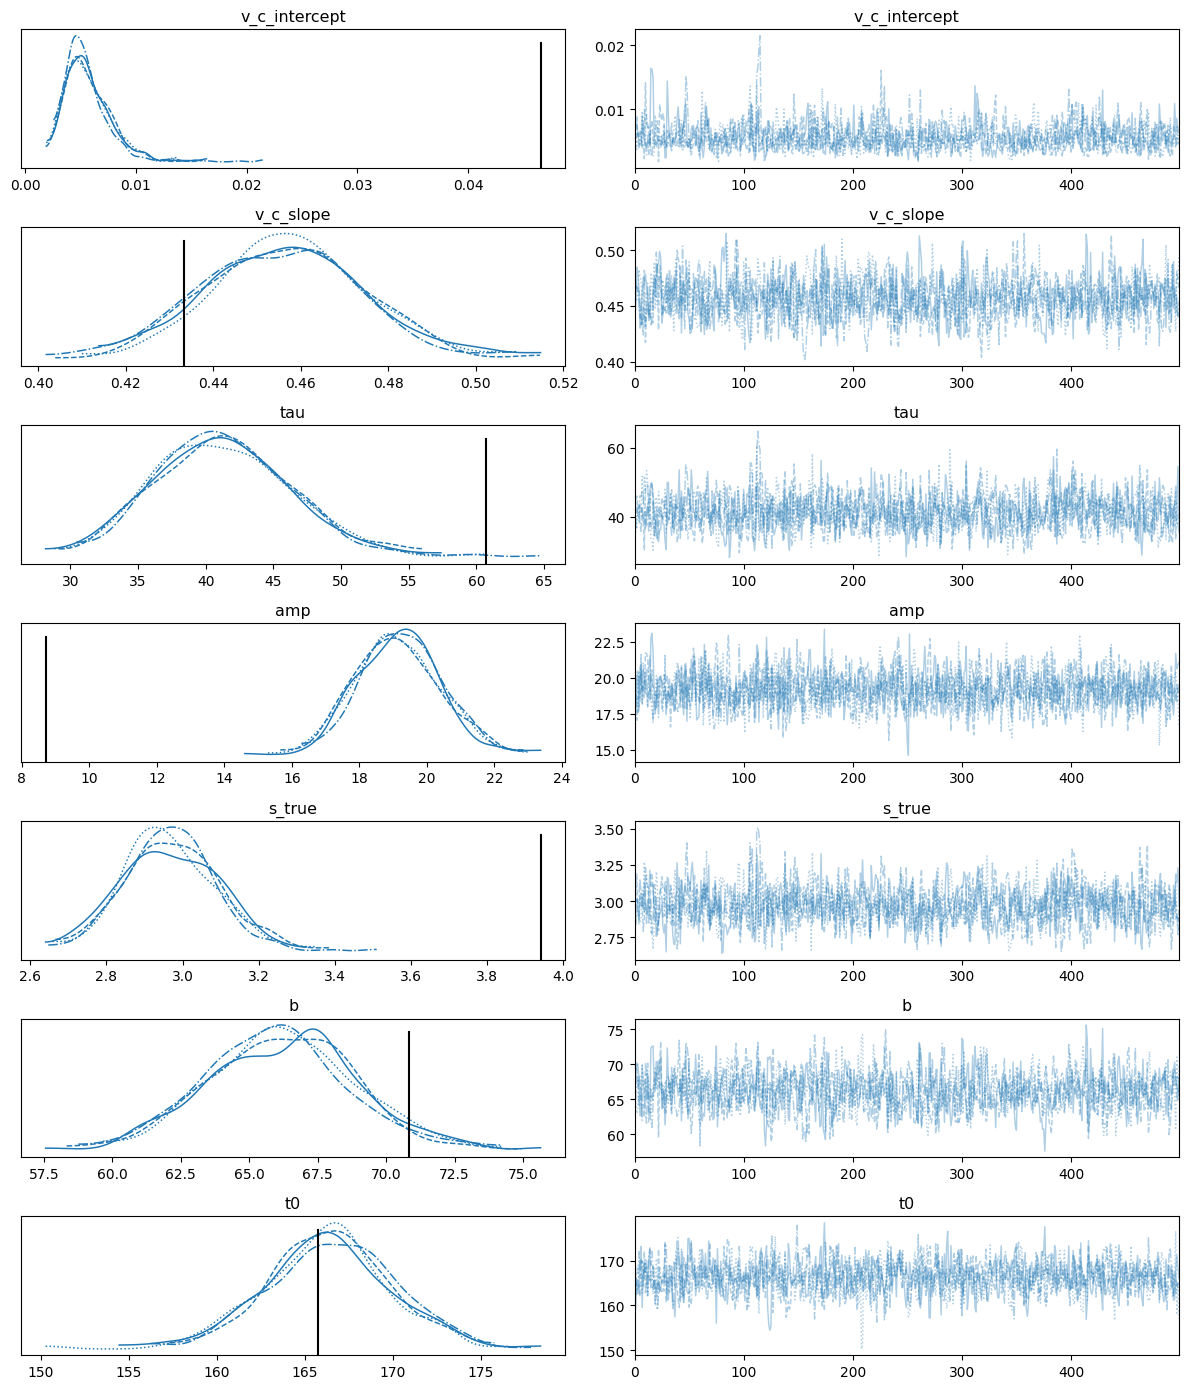

In [19]:
import matplotlib.pyplot as plt
import arviz as az

reference_values = {
    key: val for key, val in zip(param_names, prior_draws)
}

idata = az.from_dict(
    posterior={k: v
               for k, v in zip(param_names, np.moveaxis(np.exp(trace.position), (0, 1, 2), (2, 1, 0)))})
ax = az.plot_trace(idata)

for i, p in enumerate(prior_draws):
    ax[i, 0].axvline(p, 0, 0.9, color="k")

plt.tight_layout()

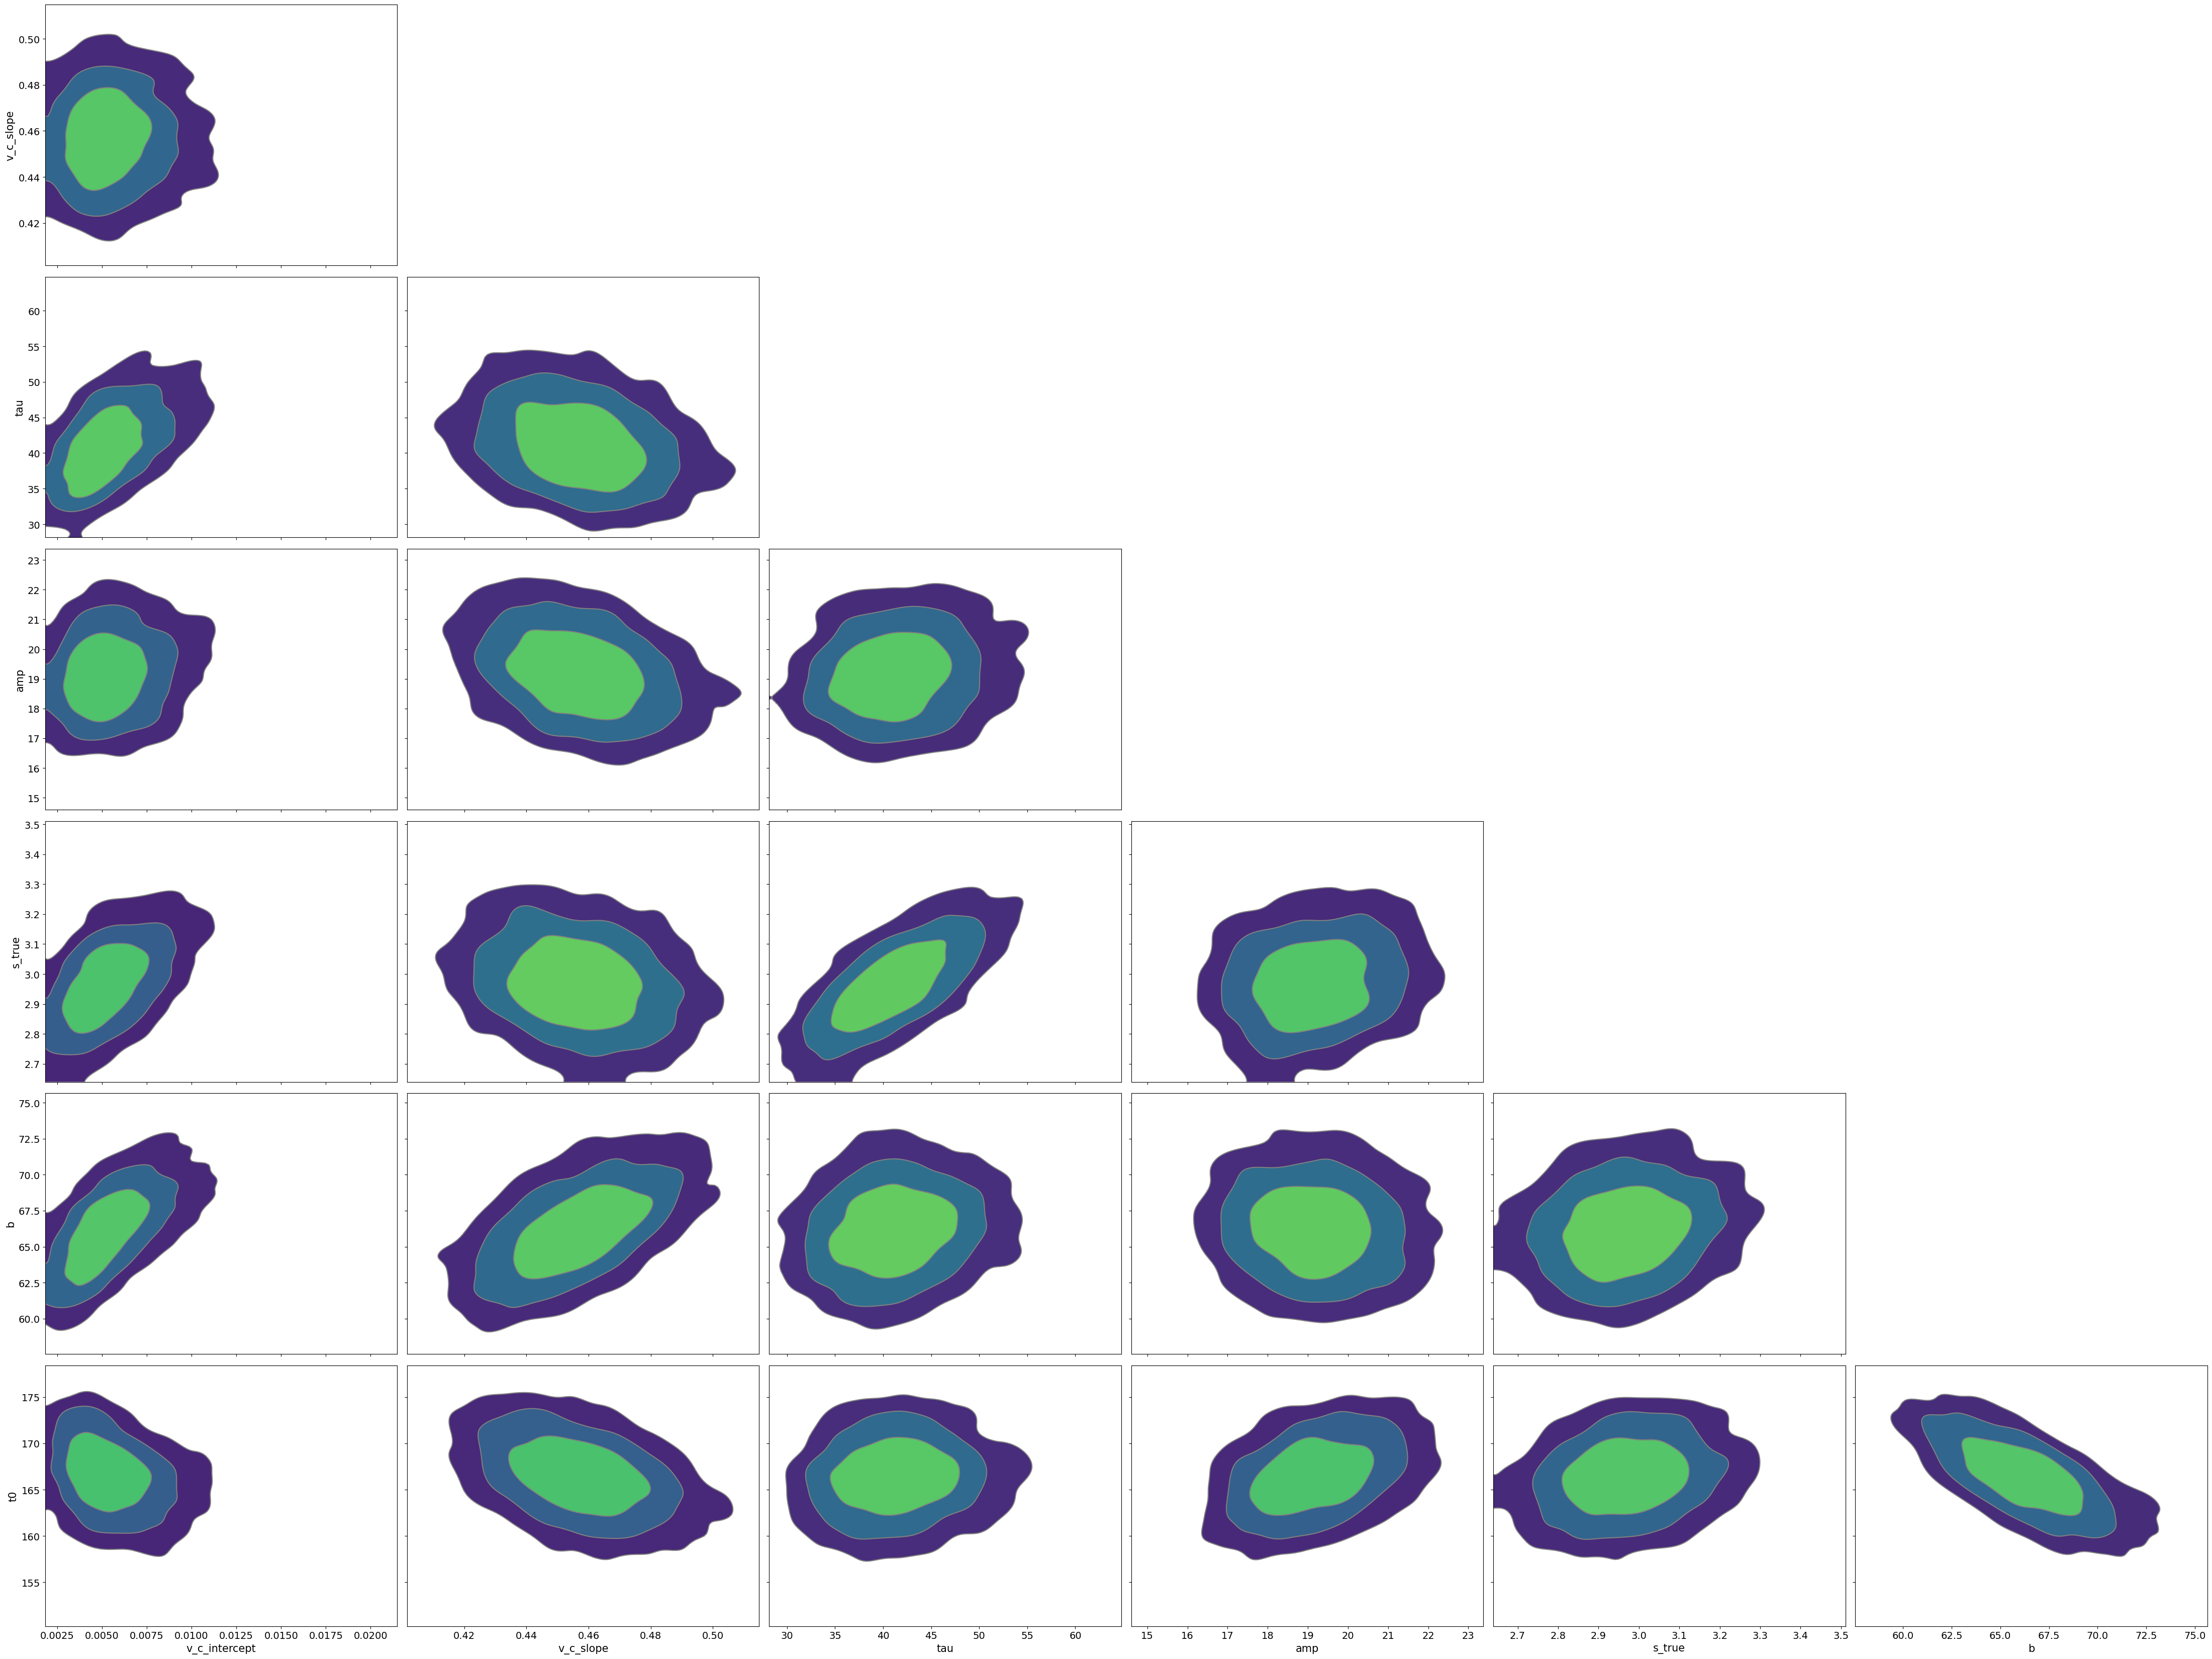

In [20]:
az.plot_pair(idata, kind="kde")
plt.tight_layout()